# Biosignal Analysis Full Notebook
발표/시연용 전체 분석 노트북

## 1. 라이브러리 불러오기

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 160

## 2. 경로 설정
노트북이 `src` 폴더 안에 있다고 가정하고, 상위 폴더의 `data`, `figures`를 사용합니다.

In [2]:
PROJECT_DIR = Path().resolve().parent
DATA_DIR = PROJECT_DIR / 'data'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

RAW_PATH = DATA_DIR / 'biosignal_raw_long_simulated.csv'

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_PATH:", RAW_PATH)
print("CSV exists:", RAW_PATH.exists())

PROJECT_DIR: C:\datamining_midterm_project
RAW_PATH: C:\datamining_midterm_project\data\biosignal_raw_long_simulated.csv
CSV exists: True


## 3. 원본 데이터 불러오기

In [3]:
raw_df = pd.read_csv(RAW_PATH)
raw_df.head(20)

,timestamp,device_id,data_category,min_value,avg_value,max_value
0,1740787200,661,14211,1.0,1.0,1.0
1,1740787200,661,14215,0.0,0.0,0.0
2,1740787200,661,14221,12.4,12.5,12.7
3,1740787200,661,14223,60.0,61.5,62.5
4,1740787260,661,14211,1.0,1.0,1.0
5,1740787260,661,14215,0.0,0.0,0.0
6,1740787260,661,14221,12.4,12.6,13.2
7,1740787260,661,14223,58.5,59.5,60.1
8,1740787320,661,14211,1.0,1.0,1.0
9,1740787320,661,14215,0.0,0.0,0.0


## 4. Long format → Wide format 변환
`data_category`별로 나뉜 데이터를 한 행으로 합칩니다.

In [4]:
wide_df = raw_df.pivot_table(
    index=['timestamp', 'device_id'],
    columns='data_category',
    values='avg_value',
    aggfunc='mean'
).reset_index()

wide_df.columns = ['timestamp', 'device_id', 'Status', 'Drop', 'Breath', 'Heart']
wide_df['datetime'] = pd.to_datetime(wide_df['timestamp'], unit='s')
wide_df = wide_df[['datetime', 'timestamp', 'device_id', 'Status', 'Breath', 'Heart', 'Drop']].sort_values('datetime').reset_index(drop=True)

wide_df.head()

,datetime,timestamp,device_id,Status,Breath,Heart,Drop
0,2025-03-01 00:00:00,1740787200,661,1.0,12.5,61.5,0.0
1,2025-03-01 00:01:00,1740787260,661,1.0,12.6,59.5,0.0
2,2025-03-01 00:02:00,1740787320,661,1.0,11.5,58.8,0.0
3,2025-03-01 00:03:00,1740787380,661,1.0,11.1,59.7,0.0
4,2025-03-01 00:04:00,1740787440,661,1.0,11.2,63.6,0.0


## 5. 전처리
- 결측치 제거
- `Status == 1` 인 재실 데이터만 사용
- Heart: 45~130, Breath: 8~30 범위만 사용

In [5]:
clean_df = wide_df.dropna(subset=['Heart', 'Breath', 'Status', 'Drop']).copy()
clean_df = clean_df[clean_df['Status'] == 1]
clean_df = clean_df[(clean_df['Heart'].between(45, 130)) & (clean_df['Breath'].between(8, 30))].copy()

clean_df.head()

,datetime,timestamp,device_id,Status,Breath,Heart,Drop
0,2025-03-01 00:00:00,1740787200,661,1.0,12.5,61.5,0.0
1,2025-03-01 00:01:00,1740787260,661,1.0,12.6,59.5,0.0
2,2025-03-01 00:02:00,1740787320,661,1.0,11.5,58.8,0.0
3,2025-03-01 00:03:00,1740787380,661,1.0,11.1,59.7,0.0
4,2025-03-01 00:04:00,1740787440,661,1.0,11.2,63.6,0.0


## 6. 파생 변수 생성
- 5개 이동평균
- 변화량(diff)
- 시간(hour), 날짜(date)

In [6]:
clean_df['heart_roll5'] = clean_df['Heart'].rolling(5, min_periods=1).mean().round(2)
clean_df['breath_roll5'] = clean_df['Breath'].rolling(5, min_periods=1).mean().round(2)
clean_df['heart_delta'] = clean_df['Heart'].diff().fillna(0).round(2)
clean_df['breath_delta'] = clean_df['Breath'].diff().fillna(0).round(2)
clean_df['hour'] = clean_df['datetime'].dt.hour
clean_df['date'] = clean_df['datetime'].dt.date.astype(str)

clean_df.head()

,datetime,timestamp,device_id,Status,Breath,Heart,Drop,heart_roll5,breath_roll5,heart_delta,breath_delta,hour,date
0,2025-03-01 00:00:00,1740787200,661,1.0,12.5,61.5,0.0,61.50,12.50,0.0,0.0,0,2025-03-01
1,2025-03-01 00:01:00,1740787260,661,1.0,12.6,59.5,0.0,60.50,12.55,-2.0,0.1,0,2025-03-01
2,2025-03-01 00:02:00,1740787320,661,1.0,11.5,58.8,0.0,59.93,12.20,-0.7,-1.1,0,2025-03-01
3,2025-03-01 00:03:00,1740787380,661,1.0,11.1,59.7,0.0,59.88,11.92,0.9,-0.4,0,2025-03-01
4,2025-03-01 00:04:00,1740787440,661,1.0,11.2,63.6,0.0,60.62,11.78,3.9,0.1,0,2025-03-01


## 7. 중간 결과 저장

In [7]:
wide_df.to_csv(DATA_DIR / 'biosignal_wide_before_cleaning.csv', index=False, encoding='utf-8-sig')
clean_df.to_csv(DATA_DIR / 'biosignal_processed_wide.csv', index=False, encoding='utf-8-sig')

print("saved:",
      DATA_DIR / 'biosignal_wide_before_cleaning.csv',
      DATA_DIR / 'biosignal_processed_wide.csv',
      sep='\n')

saved:
C:\datamining_midterm_project\data\biosignal_wide_before_cleaning.csv
C:\datamining_midterm_project\data\biosignal_processed_wide.csv


## 8. 요약 통계 계산

In [8]:
duplicate_count = int(raw_df.duplicated(subset=['timestamp', 'device_id', 'data_category'], keep=False).sum())

summary = {
    'raw_rows': int(len(raw_df)),
    'wide_rows_before_cleaning': int(len(wide_df)),
    'analysis_rows_after_cleaning': int(len(clean_df)),
    'duplicate_raw_rows': duplicate_count,
    'missing_heart_rows': int(wide_df['Heart'].isna().sum()),
    'missing_breath_rows': int(wide_df['Breath'].isna().sum()),
    'heart_outlier_rows': int(((wide_df['Heart'] > 130) | ((wide_df['Heart'] > 0) & (wide_df['Heart'] < 45))).sum()),
    'breath_outlier_rows': int(((wide_df['Breath'] > 30) | ((wide_df['Breath'] > 0) & (wide_df['Breath'] < 8))).sum()),
    'present_minutes_before_cleaning': int((wide_df['Status'] == 1).sum()),
    'absent_minutes_before_cleaning': int((wide_df['Status'] == 0).sum()),
    'drop_events_after_cleaning': int(clean_df['Drop'].sum()),
    'heart_breath_correlation': round(float(clean_df[['Heart', 'Breath']].corr().iloc[0, 1]), 3),
}

desc = clean_df[['Heart', 'Breath']].describe().round(2)

summary.update({
    'heart_mean': float(desc.loc['mean', 'Heart']),
    'heart_std': float(desc.loc['std', 'Heart']),
    'heart_min': float(desc.loc['min', 'Heart']),
    'heart_max': float(desc.loc['max', 'Heart']),
    'breath_mean': float(desc.loc['mean', 'Breath']),
    'breath_std': float(desc.loc['std', 'Breath']),
    'breath_min': float(desc.loc['min', 'Breath']),
    'breath_max': float(desc.loc['max', 'Breath']),
})

summary

{'raw_rows': 80600,
 'wide_rows_before_cleaning': 20160,
 'analysis_rows_after_cleaning': 17960,
 'duplicate_raw_rows': 240,
 'missing_heart_rows': 81,
 'missing_breath_rows': 79,
 'heart_outlier_rows': 30,
 'breath_outlier_rows': 25,
 'present_minutes_before_cleaning': 18240,
 'absent_minutes_before_cleaning': 1920,
 'drop_events_after_cleaning': 8,
 'heart_breath_correlation': 0.867,
 'heart_mean': 72.14,
 'heart_std': 11.08,
 'heart_min': 51.8,
 'heart_max': 117.2,
 'breath_mean': 15.15,
 'breath_std': 3.28,
 'breath_min': 9.1,
 'breath_max': 29.3}

## 9. 요약 파일 저장

In [9]:
(DATA_DIR / 'analysis_summary.json').write_text(
    json.dumps(summary, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

preprocess_table = pd.DataFrame([
    ['Raw long rows', len(raw_df), 'Includes duplicates and partial missing rows'],
    ['After pivot', len(wide_df), 'One row per timestamp'],
    ['After missing removal', len(wide_df.dropna(subset=['Heart', 'Breath', 'Status', 'Drop'])), 'Removed partial timestamps'],
    ['After presence filter', len(wide_df.dropna(subset=['Heart', 'Breath', 'Status', 'Drop'])[wide_df.dropna(subset=['Heart', 'Breath', 'Status', 'Drop'])['Status'] == 1]), 'Removed absent periods'],
    ['Final cleaned rows', len(clean_df), 'Heart 45-130, Breath 8-30'],
], columns=['step', 'rows', 'note'])

preprocess_table.to_csv(DATA_DIR / 'preprocessing_summary.csv', index=False, encoding='utf-8-sig')
desc.to_csv(DATA_DIR / 'descriptive_statistics.csv', encoding='utf-8-sig')

preprocess_table

,step,rows,note
0,Raw long rows,80600,Includes duplicates and partial missing rows
1,After pivot,20160,One row per timestamp
2,After missing removal,20000,Removed partial timestamps
3,After presence filter,18095,Removed absent periods
4,Final cleaned rows,17960,"Heart 45-130, Breath 8-30"


## 10. 전처리 퍼널 그래프

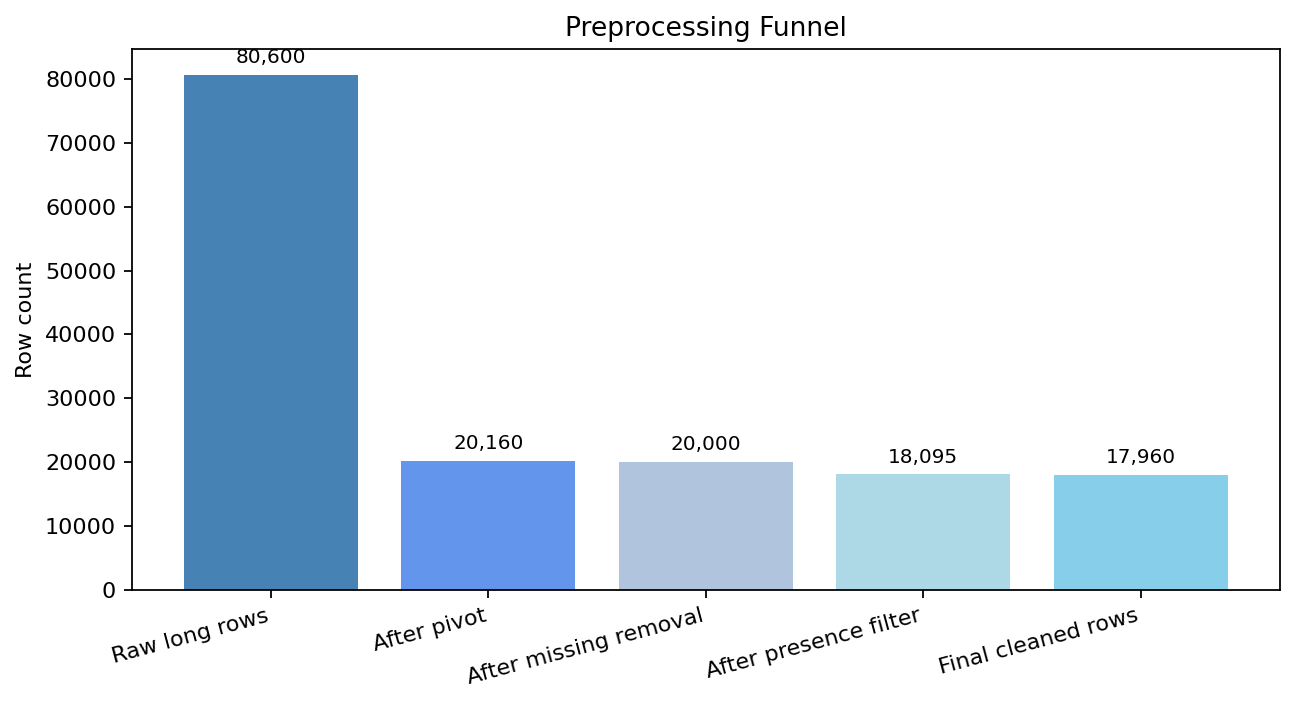

In [10]:
plt.figure(figsize=(8.2, 4.5))
bars = plt.bar(preprocess_table['step'], preprocess_table['rows'], color=['steelblue', 'cornflowerblue', 'lightsteelblue', 'lightblue', 'skyblue'])
plt.title('Preprocessing Funnel')
plt.ylabel('Row count')
plt.xticks(rotation=15, ha='right')
for b, v in zip(bars, preprocess_table['rows']):
    plt.text(b.get_x() + b.get_width() / 2, v + max(preprocess_table['rows']) * 0.015, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 11. 재실/부재 상태 분포

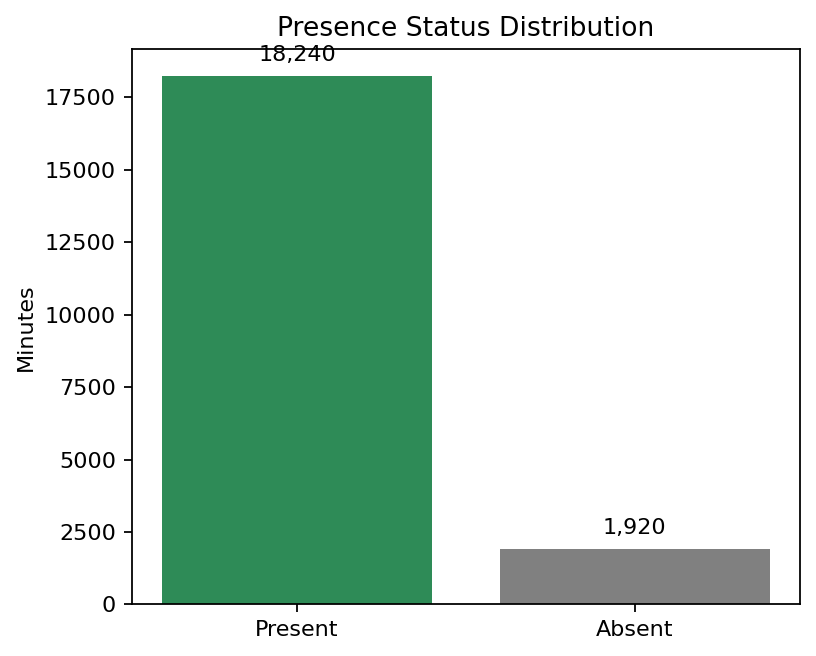

In [11]:
counts = pd.Series({
    'Present': summary['present_minutes_before_cleaning'],
    'Absent': summary['absent_minutes_before_cleaning']
})

plt.figure(figsize=(5.2, 4.2))
bars = plt.bar(counts.index, counts.values, color=['seagreen', 'gray'])
plt.title('Presence Status Distribution')
plt.ylabel('Minutes')
for b, v in zip(bars, counts.values):
    plt.text(b.get_x() + b.get_width() / 2, v + counts.max() * 0.02, f'{v:,}', ha='center', va='bottom', fontsize=10, )
plt.tight_layout()
plt.show()

## 12. 72시간 심박/호흡 타임라인

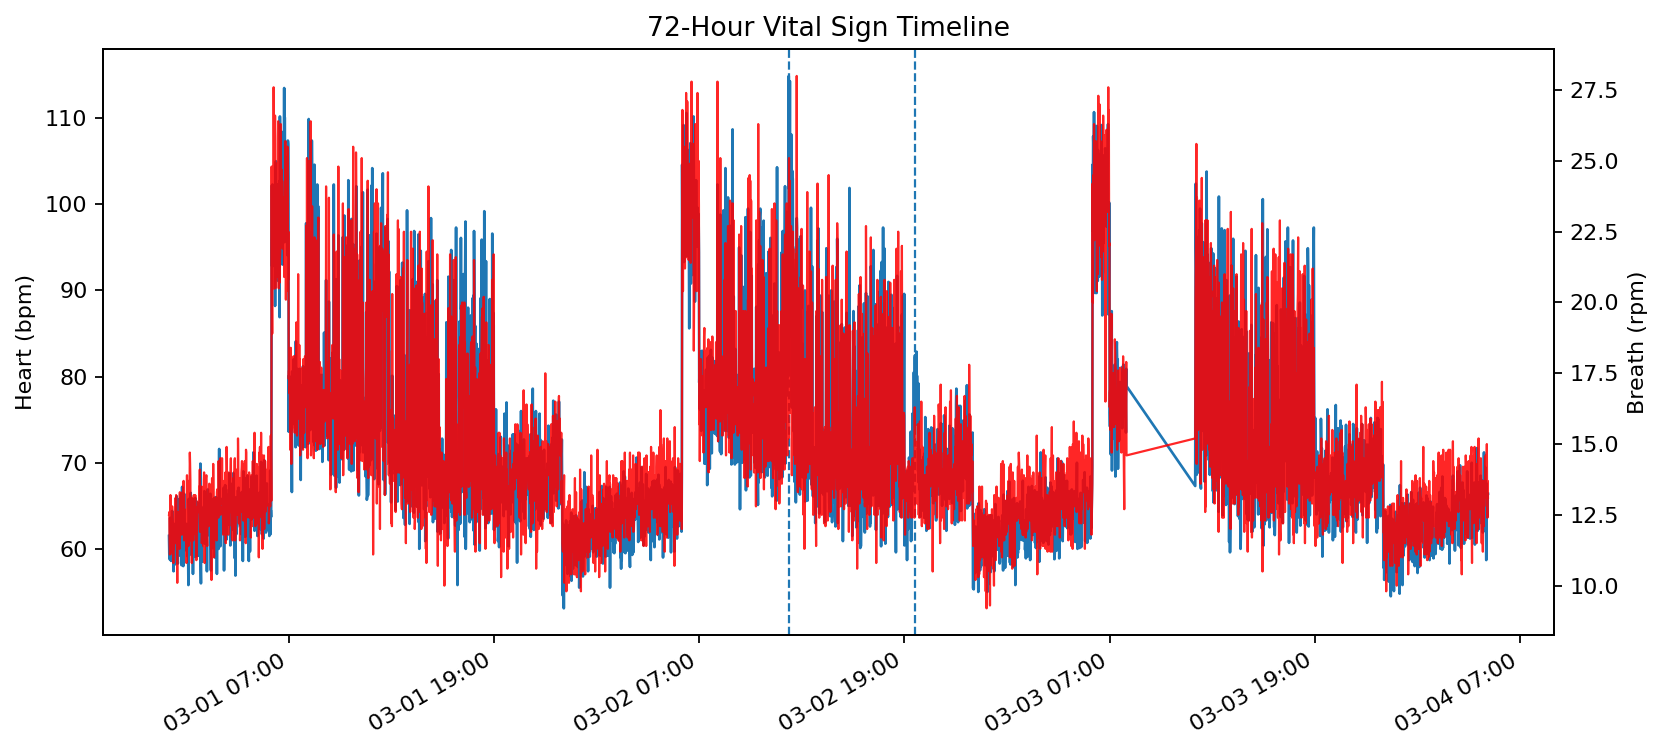

In [12]:
timeline = clean_df.iloc[:72 * 60].copy()

fig, ax1 = plt.subplots(figsize=(10.5, 4.8))
ax1.plot(timeline['datetime'], timeline['Heart'], label='Heart (bpm)', linewidth=1.2)
ax1.set_ylabel('Heart (bpm)')
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

ax2 = ax1.twinx()
ax2.plot(timeline['datetime'], timeline['Breath'], label='Breath (rpm)', linewidth=1.0, alpha=0.85, color='red')
ax2.set_ylabel('Breath (rpm)')

for d in timeline[timeline['Drop'] == 1]['datetime']:
    ax1.axvline(d, linestyle='--', linewidth=1)

plt.title('72-Hour Vital Sign Timeline')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 13. Heart / Breath 분포

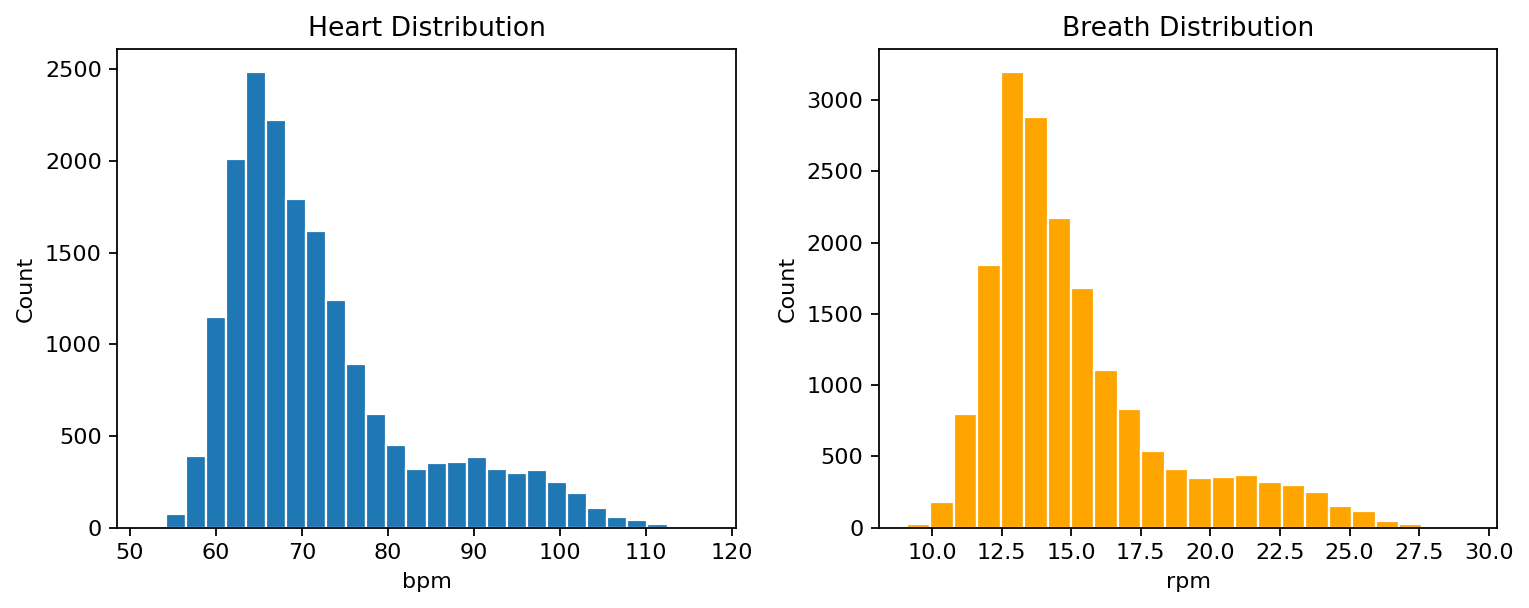

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))

axes[0].hist(clean_df['Heart'], bins=28, edgecolor='white')
axes[0].set_title('Heart Distribution')
axes[0].set_xlabel('bpm')
axes[0].set_ylabel('Count')

axes[1].hist(clean_df['Breath'], bins=24, edgecolor='white', color='orange')
axes[1].set_title('Breath Distribution')
axes[1].set_xlabel('rpm')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 14. Heart vs Breath 상관관계

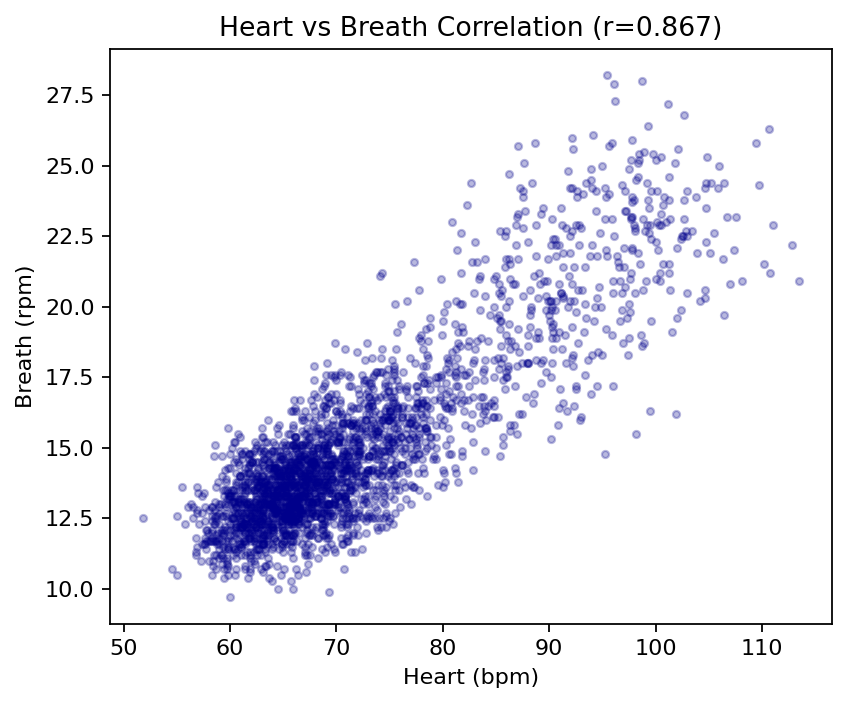

In [14]:
sample = clean_df.sample(n=min(2500, len(clean_df)), random_state=42)

plt.figure(figsize=(5.4, 4.5))
plt.scatter(sample['Heart'], sample['Breath'], s=10, alpha=0.28, color='darkblue')
plt.title(f'Heart vs Breath Correlation (r={summary["heart_breath_correlation"]})')
plt.xlabel('Heart (bpm)')
plt.ylabel('Breath (rpm)')
plt.tight_layout()
plt.show()

## 15. 낙상 이벤트 전후 구간

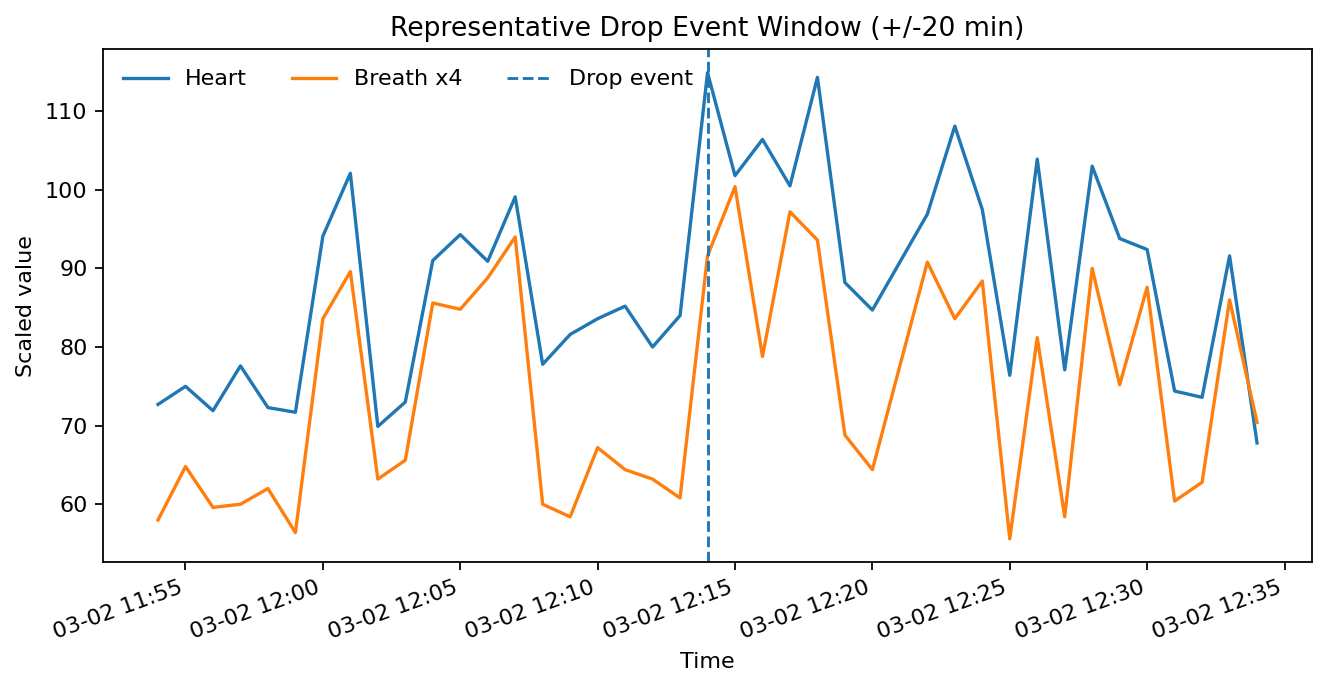

In [15]:
if clean_df['Drop'].sum() > 0:
    drop_idx = clean_df.index[clean_df['Drop'] == 1][0]
    window = clean_df.loc[max(drop_idx - 20, clean_df.index.min()): min(drop_idx + 20, clean_df.index.max())].copy()

    plt.figure(figsize=(8.4, 4.4))
    plt.plot(window['datetime'], window['Heart'], label='Heart', linewidth=1.5)
    plt.plot(window['datetime'], window['Breath'] * 4, label='Breath x4', linewidth=1.5)
    drop_time = clean_df.loc[drop_idx, 'datetime']
    plt.axvline(drop_time, linestyle='--', linewidth=1.3, label='Drop event')
    plt.title('Representative Drop Event Window (+/-20 min)')
    plt.ylabel('Scaled value')
    plt.xlabel('Time')
    plt.legend(frameon=False, ncol=3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No drop events found.")

## 16. 시간대별 평균 패턴

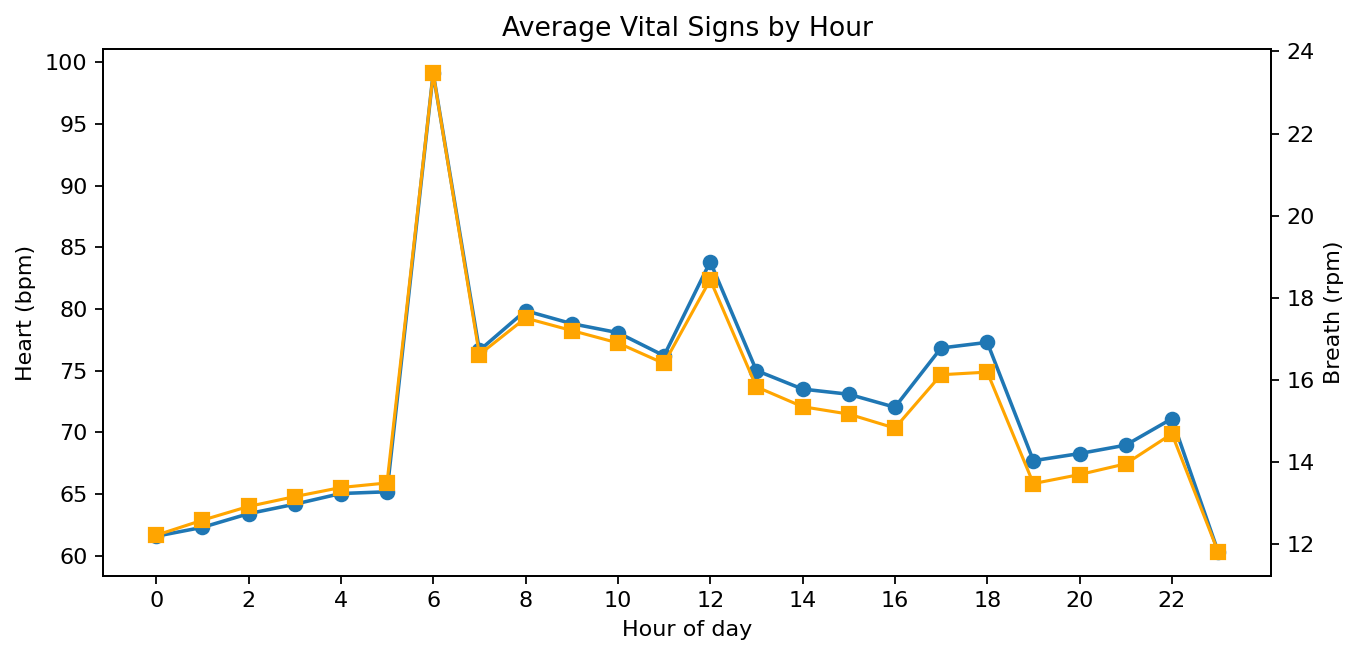

In [16]:
hourly = clean_df.groupby('hour')[['Heart', 'Breath']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(8.6, 4.2))
ax1.plot(hourly['hour'], hourly['Heart'], marker='o', linewidth=1.6)
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Heart (bpm)')
ax1.set_xticks(range(0, 24, 2))

ax2 = ax1.twinx()
ax2.plot(hourly['hour'], hourly['Breath'], marker='s', linewidth=1.4, color='orange')
ax2.set_ylabel('Breath (rpm)')

plt.title('Average Vital Signs by Hour')
plt.tight_layout()
plt.show()

## 17. 최종 요약 출력

In [17]:
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "raw_rows": 80600,
  "wide_rows_before_cleaning": 20160,
  "analysis_rows_after_cleaning": 17960,
  "duplicate_raw_rows": 240,
  "missing_heart_rows": 81,
  "missing_breath_rows": 79,
  "heart_outlier_rows": 30,
  "breath_outlier_rows": 25,
  "present_minutes_before_cleaning": 18240,
  "absent_minutes_before_cleaning": 1920,
  "drop_events_after_cleaning": 8,
  "heart_breath_correlation": 0.867,
  "heart_mean": 72.14,
  "heart_std": 11.08,
  "heart_min": 51.8,
  "heart_max": 117.2,
  "breath_mean": 15.15,
  "breath_std": 3.28,
  "breath_min": 9.1,
  "breath_max": 29.3
}
